In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_nodes_from(['João', 'Paulo', 'Maria', 'Joana', 'Antonia', 'Lili', 'Raimundo'])

In [6]:
G.add_edges_from([
   ('João', 'Paulo'),
    ('Paulo', 'Maria'),
    ('Paulo', 'Joana'),
    ('Paulo', 'Antonia'),
    ('Paulo', 'Lili'),
    ('Maria', 'Joana'),
    ('Joana', 'Antonia'),
    ('Antonia', 'Lili')])


In [7]:
pessoas = list(G.nodes())
for pessoa in pessoas:
    vizinhos = list(G.neighbors(pessoa))

    vizinhos_str = "{" + ", ".join(vizinhos) + "}"
    print(f"• {pessoa}: {vizinhos_str}")

    matriz = nx.to_pandas_adjacency(G, nodelist=pessoas, dtype=int)
print(matriz)

• João: {Paulo}
• Paulo: {João, Maria, Joana, Antonia, Lili}
• Maria: {Paulo, Joana}
• Joana: {Paulo, Maria, Antonia}
• Antonia: {Paulo, Joana, Lili}
• Lili: {Paulo, Antonia}
• Raimundo: {}
          João  Paulo  Maria  Joana  Antonia  Lili  Raimundo
João         0      1      0      0        0     0         0
Paulo        1      0      1      1        1     1         0
Maria        0      1      0      1        0     0         0
Joana        0      1      1      0        1     0         0
Antonia      0      1      0      1        0     1         0
Lili         0      1      0      0        1     0         0
Raimundo     0      0      0      0        0     0         0


In [8]:
graus = dict(G.degree())
maior_grau = max(graus.values())
menor_grau = min(graus.values())

pessoas_maior = [p for p, g in graus.items() if g == maior_grau]
pessoas_menor = [p for p, g in graus.items() if g == menor_grau]

In [9]:
print(f"– Maior Grau (Máximo): {', '.join(pessoas_maior)} com grau {maior_grau} ({maior_grau} conexões).")
print(f"– Menor Grau (Mínimo): {', '.join(pessoas_menor)} com grau {menor_grau} ({menor_grau} conexões - vértice isolado).")

– Maior Grau (Máximo): Paulo com grau 5 (5 conexões).
– Menor Grau (Mínimo): Raimundo com grau 0 (0 conexões - vértice isolado).


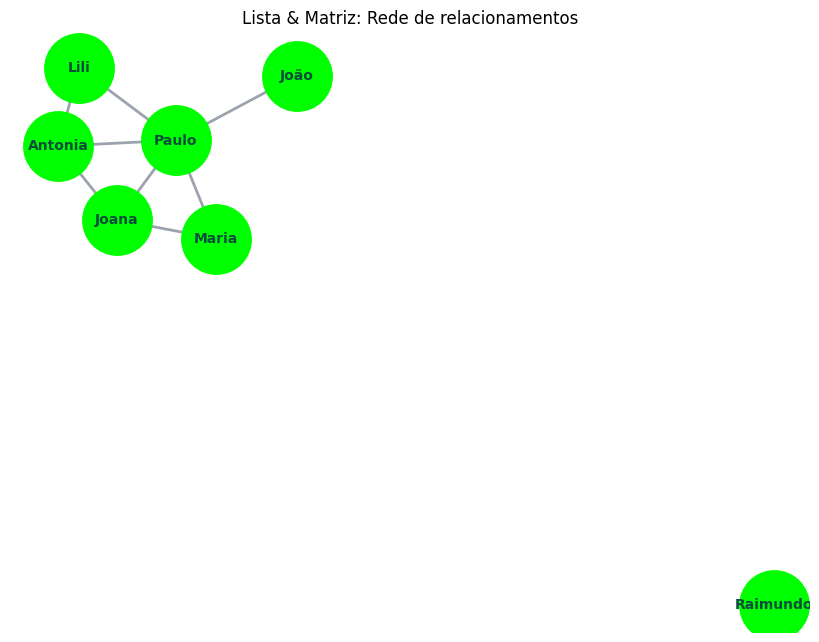

In [10]:
plt.figure(figsize=(8, 6))
posicoes = nx.spring_layout(G, seed=42)

nx.draw(G, posicoes, with_labels=True, node_color='#00FF00', node_size=2500,
        font_size=10, font_weight='bold', font_color='#064E3B', edge_color='#9CA3AF', width=2)

plt.title("Lista & Matriz: Rede de relacionamentos")
plt.show()